In [1]:
import anndata
import scgenome.plotting as pl
from cellmates.utils.benchmarking import get_sconce2_cn_matrix, read_chisel_clones

/proj/sc_ml/shared/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/proj/sc_ml/shared/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
adata_path = "/proj/sc_ml/shared/s0_10x/5M/merged_5M_N500_E.h5ad"
sconce2_out_dir = "/proj/sc_ml/shared/s0_10x/5M/sconce2_out"
chisel_clones_path = "/proj/sc_ml/users/x_vitza/chisel-data/patientS0/clones/sectionE/mapping.tsv.gz"

In [3]:
adata = anndata.read_h5ad(adata_path)
print(adata)

AnnData object with n_obs × n_vars = 856 × 620
    obs: 'region', 'normal', 'clone', 'cluster'
    var: 'chr', 'start', 'end'
    layers: 'Acount', 'Bcount', 'cnA', 'cnB'


In [7]:
adata.obs_names = [o.split('-')[0] for o in adata.obs_names]

In [14]:
cell_names = adata.obs_names[~adata.obs['normal']]
sconce2_cn, _ = get_sconce2_cn_matrix(sconce2_out_dir, cn_type='median', cell_names=[c+'-5' for c in cell_names])
cell_names = [cell_name.split("_")[0] for cell_name in cell_names]
sconce2_cn_full = adata.layers['cnA'].copy()
sconce2_cn_full[adata.obs['normal']] = 2
sconce2_cn_full[~adata.obs['normal']] = sconce2_cn
adata.layers['sconce2_cn_median'] = sconce2_cn_full

Determined k=6 from bed file /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__CCGTTCAAGACTAAGT-5.bed__k6__median.bed
Determined n_bins=620
scanning /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__CCGTTCAAGACTAAGT-5.bed__k6__median.bed
- found! cell_name: CCGTTCAAGACTAAGT-5, cell_idx -> cell_names[121]
scanning /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__CACTCCACACGTACAT-5.bed__k6__median.bed
- found! cell_name: CACTCCACACGTACAT-5, cell_idx -> cell_names[287]
scanning /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__GGGTCTGGTTACGCGC-5.bed__k6__median.bed
- found! cell_name: GGGTCTGGTTACGCGC-5, cell_idx -> cell_names[89]
scanning /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__GAACCTACAGAAAGCC-5.bed__k6__median.bed
- found! cell_name: GAACCTACAGAAAGCC-5, cell_idx -> cell_names[167]
scanning /proj/sc_ml/shared/s0_10x/5M/sconce2_out/model__GCTCTGTCAGCCAGTC-5.bed__k6__median.bed
- found! cell_name: GCTCTGTCAGCCAGTC-5, cell_idx -> cell_names[352]
scanning /proj/sc_ml/shared/s0_10x/5M/sconc

In [15]:
# add chisel clones to data
clones = read_chisel_clones(chisel_clones_path)
# add clone series to adata.obs which should have the same index
adata.obs['chisel_clone'] = clones[adata.obs_names].values

CHISEL mapping diagnostics:
  Total cells in mapping: 2075
  Unique clones: 6
  Unique clusters: 557


In [21]:
# add total copy number
adata.layers['state'] = adata.layers['cnA'] + adata.layers['cnB']

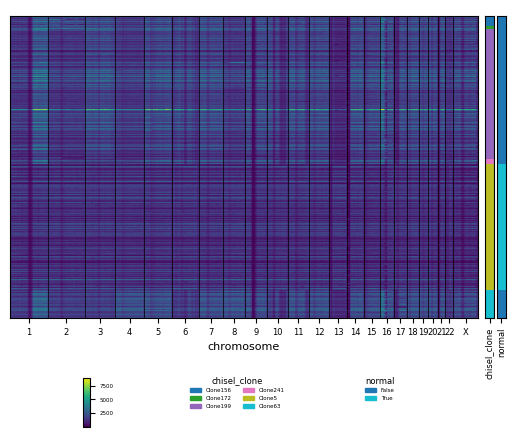

In [22]:
# plot reads
g = pl.plot_cell_cn_matrix_fig(adata, layer_name=None, cell_order_fields=['chisel_clone', 'normal'], annotation_fields=['chisel_clone', 'normal'], raw=True)

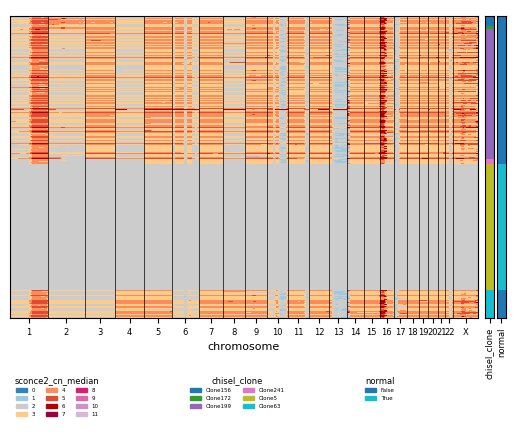

In [23]:
# plot sconce2 cn
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='sconce2_cn_median', cell_order_fields=['chisel_clone', 'normal'], annotation_fields=['chisel_clone', 'normal'])

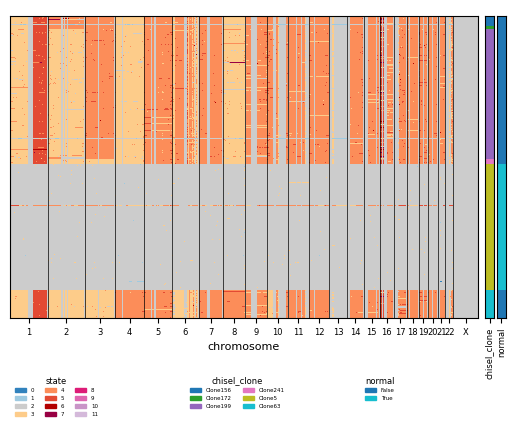

In [24]:
# plot CHISEL total copy number
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', cell_order_fields=['chisel_clone', 'normal'], annotation_fields=['chisel_clone', 'normal'])